In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/Customer Churn.csv')
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Inspection

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
## Total charges should be in float but it has 11 blank entries
df['TotalCharges'].value_counts()

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8
...,...
130.15,1
3211.9,1
7843.55,1


### Replacing blank values to 0 in total charges

In [6]:
df['TotalCharges'].replace("","0",inplace=True)
df['TotalCharges'].replace(" ","0",inplace=True)

/tmp/ipykernel_1837/2878815619.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].replace("","0",inplace=True)
/tmp/ipykernel_1837/2878815619.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [7]:
df['TotalCharges'] = df['TotalCharges'].astype("float")

In [8]:
df["TotalCharges"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7043 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


### Null Values

In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Data description

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


### Data Duplication

In [11]:
df["customerID"].duplicated().sum()

np.int64(0)

### Data transformation - INT (0/1) to OBJ (Yes/No) of Senior Citizen column

In [12]:
def convert(val):
  if val==1:
    return "Yes"
  else:
    return "No"

In [13]:
df['SeniorCitizen'] = df['SeniorCitizen'].apply(convert)

In [14]:
df['SeniorCitizen'].head()

,SeniorCitizen
0,No
1,No
2,No
3,No
4,No


## Visualizations & Analysis



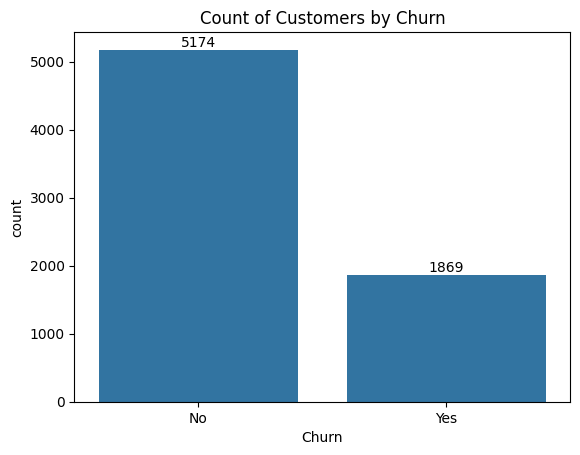

In [15]:
ax = sns.countplot(x = df['Churn'])
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Churn")
plt.show()

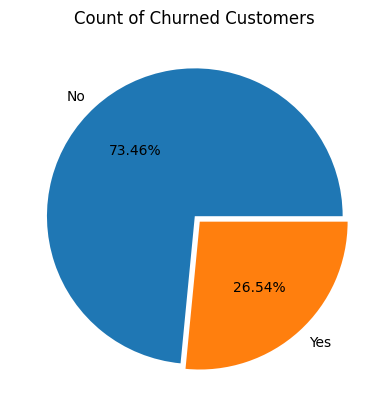

In [16]:
gb = df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'],labels=gb.index,autopct="%0.2f%%",explode=[0,0.05])
plt.title("Count of Churned Customers")
plt.show()

From given pie chart, we can analyze 26.54% of customers have churned out. Now lets explore the reason.

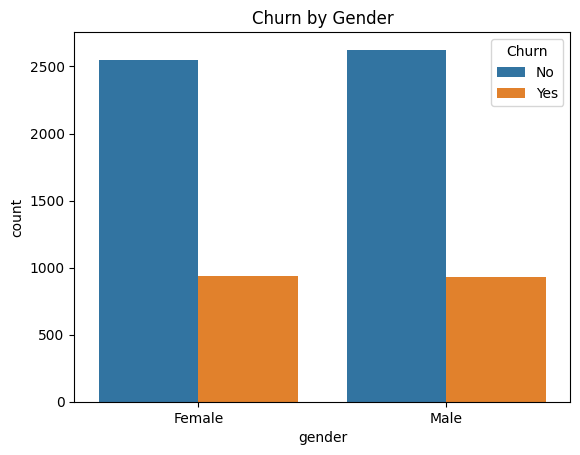

In [26]:
sns.countplot(x="gender",data = df, hue="Churn")
plt.title("Churn by Gender")
plt.show()

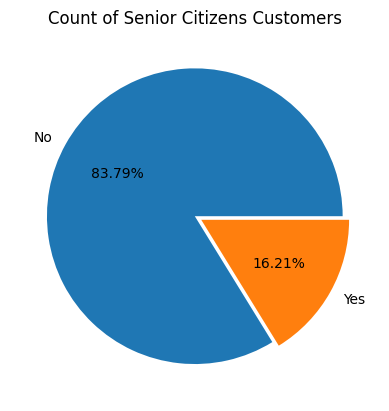

In [43]:
vc = df['SeniorCitizen'].value_counts()
plt.pie(vc,labels=vc.index,autopct="%0.2f%%",explode=[0,0.05])
plt.title("Count of Senior Citizens Customers")
plt.show()

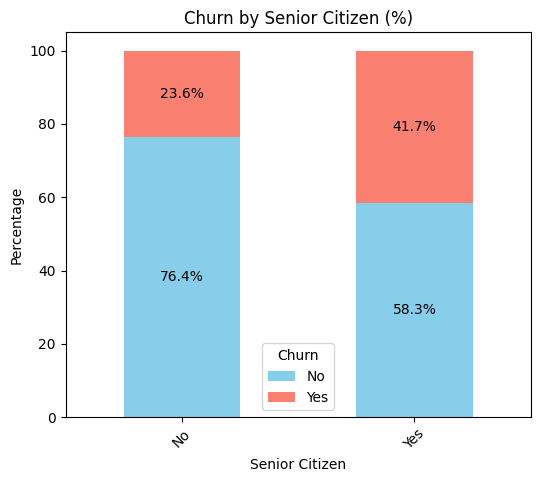

In [32]:
# Create percentage table
churn_pct = pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100

# Plot stacked bar chart
ax = churn_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(6,5),
    color=["skyblue", "salmon"]
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center",
        fontsize=10,
        color="black"
    )

plt.title("Churn by Senior Citizen (%)")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.xticks(rotation=45)
plt.show()

Comparative a greater percentage of senior citizen have churned

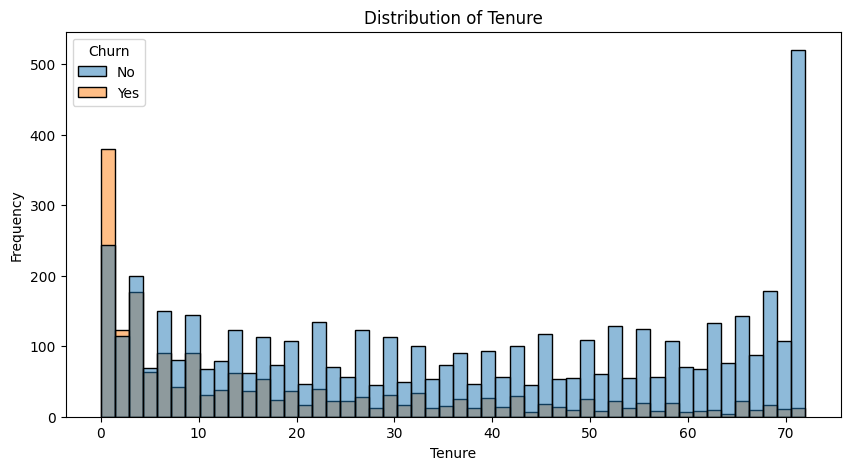

In [41]:
plt.figure(figsize=(10,5))
sns.histplot(x="tenure",data=df, bins=50,hue="Churn")
plt.xlabel("Tenure")
plt.ylabel("Frequency")
plt.title("Distribution of Tenure")
plt.show()

Most of the customers who have churned are the one's who have used our services in initial days. But who stayed with our services for longer period didnt churn.

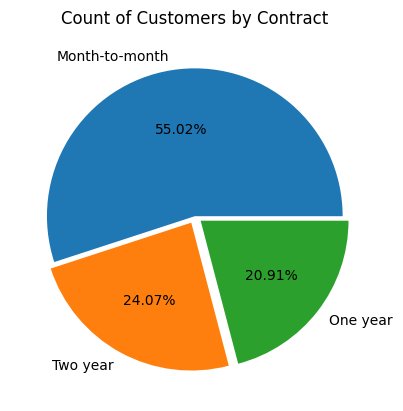

In [50]:
vc = df['Contract'].value_counts()
plt.pie(vc,labels=vc.index,autopct="%0.2f%%",explode=[0,0.05,0.05])
plt.title("Count of Customers by Contract")
plt.show()

Most of our customers give month-to-month contract commitments over two year or one year plan.

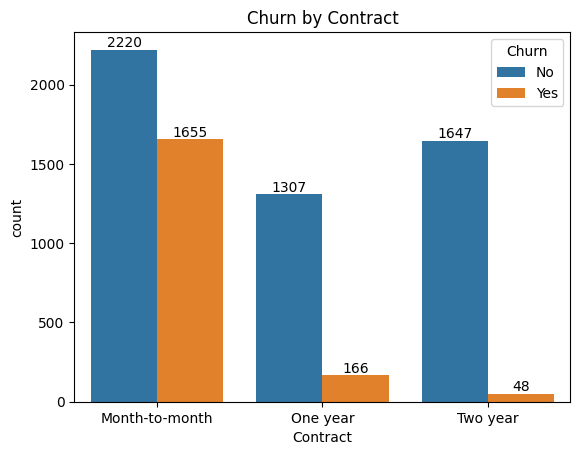

In [59]:
ax = sns.countplot(x='Contract',data=df,hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churn by Contract")
plt.show()

Most of customers are churned out in month-to-month contracts

In [61]:
ToT_Col = df.columns.values
ToT_Col

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

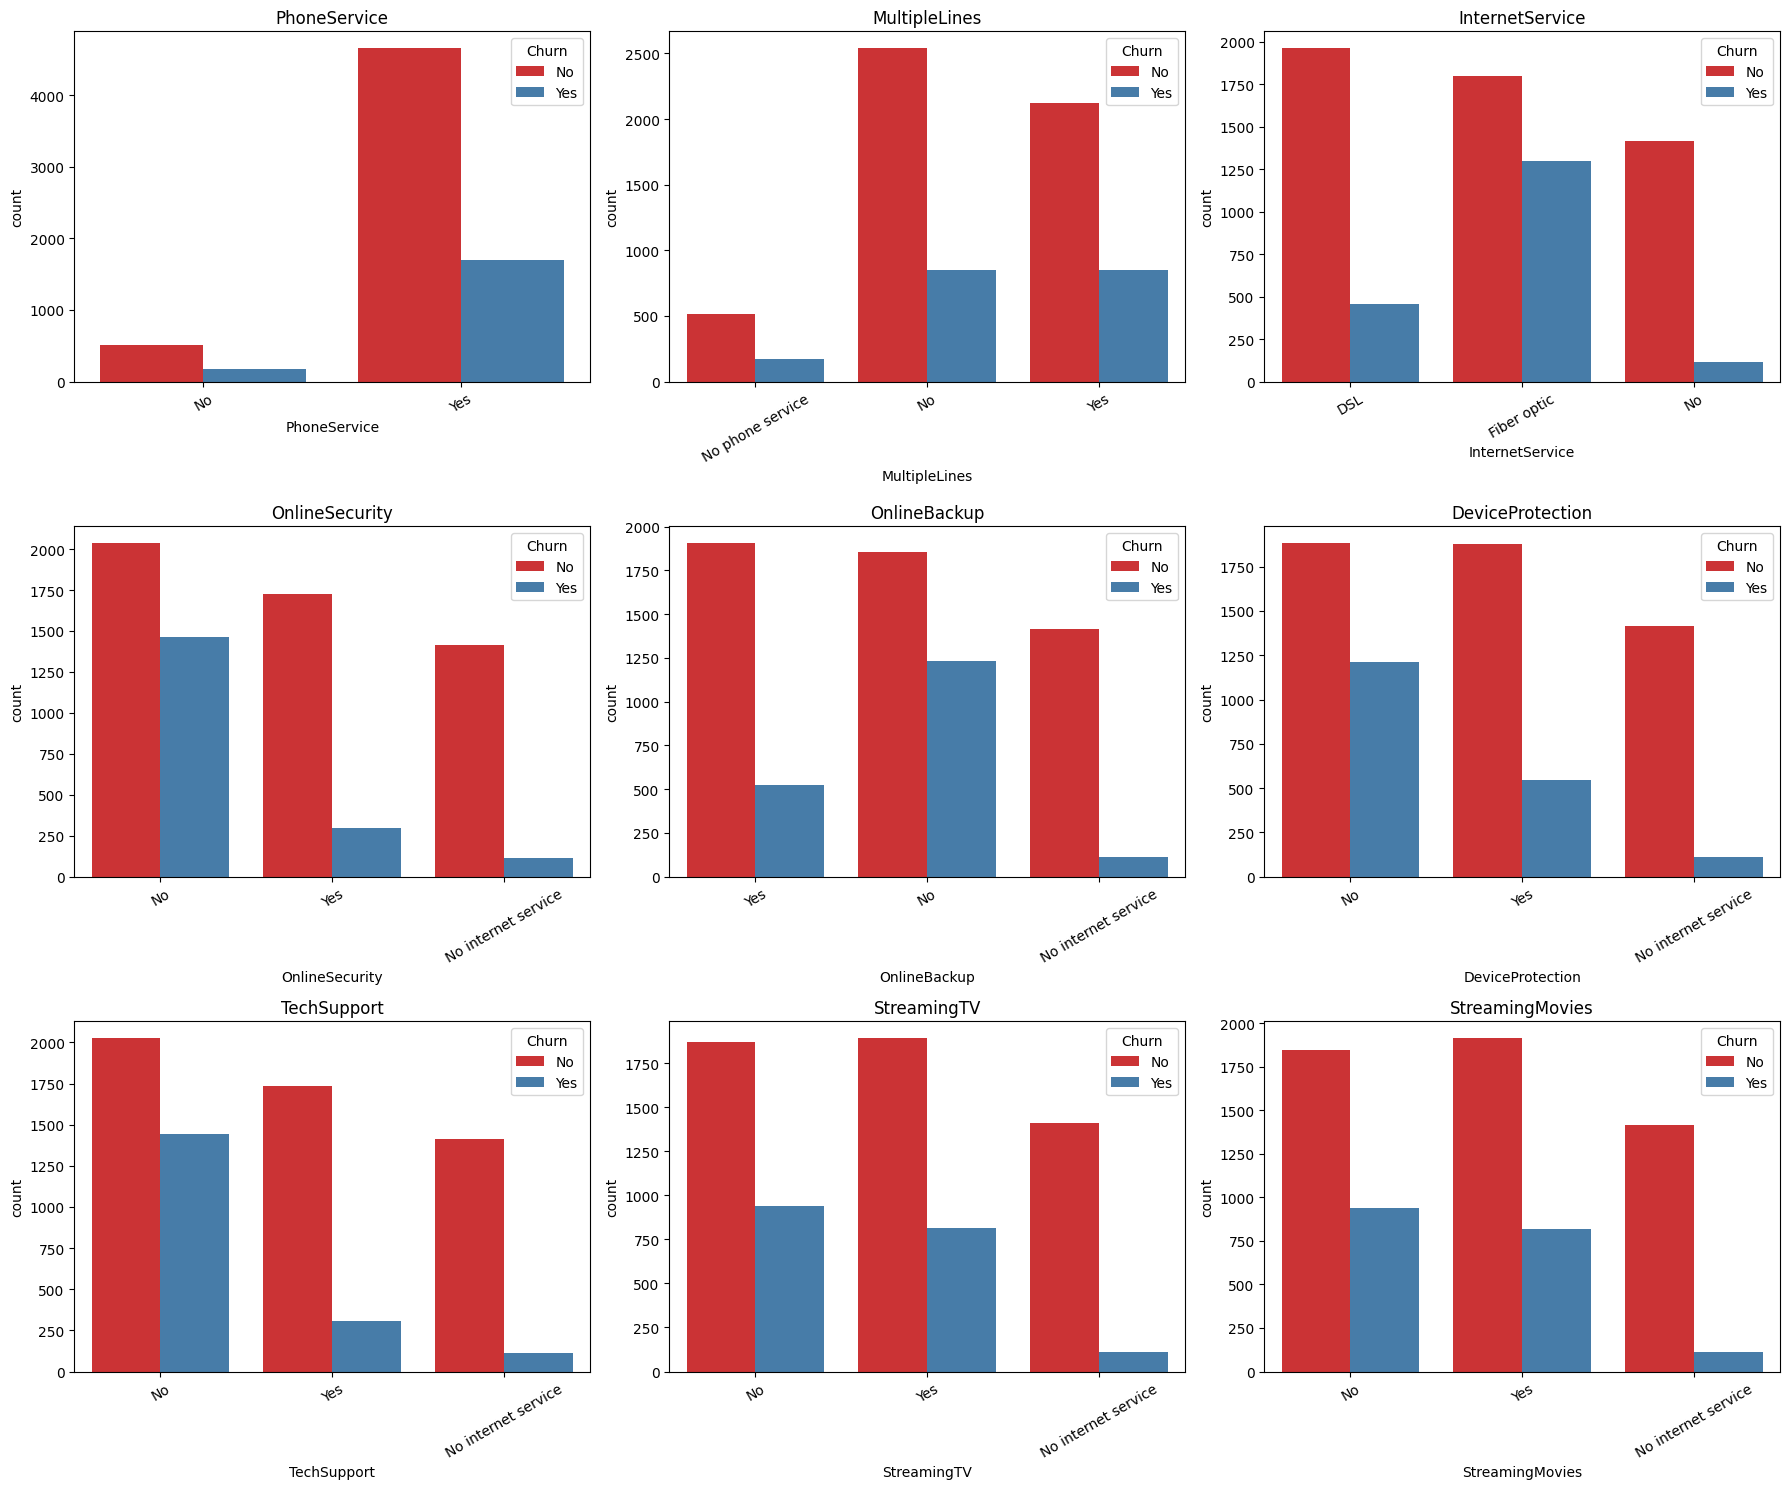

In [67]:
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(
        data=df,
        x=col,
        hue="Churn",
        ax=axes[i],
        palette="Set1"
    )
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Majority Customers using Fiber optic internet and not subscribed to support/security services are significantly more likely to churn. Customers without OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport are more likely to churn, indicating these value-added services help improve customer retention.


In contrast, PhoneService, MultipleLines, StreamingTV, and StreamingMovies show comparatively weaker relationships with churn.

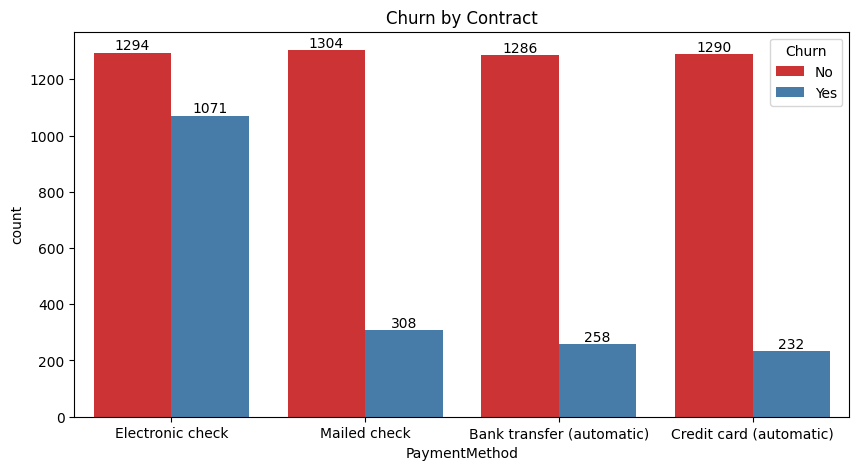

In [73]:
plt.figure(figsize=(10,5))
ax = sns.countplot(x='PaymentMethod',data=df,hue='Churn',palette="Set1")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churn by Contract")
plt.show()

Customers using Electronic Check have the highest churn, making it the payment method most associated with customer retenion and Customers using automatic payment methods (Bank Transfer and Credit Card) have the lowest churn, indicating better customer retention.

Overall, payment method significantly influences churn, with automatic payments being associated with lower churn.
